In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

import importlib
import module
importlib.reload(module)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)


METRIC_COLUMNS = [
    "Annualized Return",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Max Drawdown"
]


def buy_and_hold_curve(price_series):
    prices = price_series.to_numpy(dtype=float)

    curve = (
        prices
        / prices[0]
    )

    return pd.Series(
        curve,
        index=price_series.index
    )


def evaluate_signal_curve(price_series, signal_frame):
    delayed_signal_frame = module.apply_execution_delay(
        signal_frame,
        delay_days=1
    )

    strategy_values = module.single_signal_portfolio_values(
        price_values=price_series.to_numpy(dtype=float),
        signal_values=delayed_signal_frame["signal"].to_numpy(dtype=float),
        initial_value=1.0
    )

    strategy_curve = pd.Series(
        strategy_values,
        index=price_series.index
    )

    benchmark_curve = buy_and_hold_curve(price_series)

    strategy_stats = module.performance_statistics_from_values(
        strategy_curve.to_numpy(dtype=float)
    )

    benchmark_stats = module.performance_statistics_from_values(
        benchmark_curve.to_numpy(dtype=float)
    )

    return strategy_curve, benchmark_curve, strategy_stats, benchmark_stats


def signal_usage_statistics(signal_frame):
    signal = signal_frame["signal"].to_numpy(dtype=float)

    position_change = np.zeros(len(signal))
    position_change[1:] = np.abs(
        signal[1:]
        - signal[:-1]
    )

    active_share = np.sum(signal) / len(signal)
    number_of_trades = np.sum(position_change)

    return active_share, number_of_trades


def evaluate_candidate(price_series, signal_frame):
    strategy_curve, benchmark_curve, strategy_stats, benchmark_stats = evaluate_signal_curve(
        price_series,
        signal_frame
    )

    active_share, number_of_trades = signal_usage_statistics(
        signal_frame
    )

    strategy_stats["Active Share"] = active_share
    strategy_stats["Number of Trades"] = number_of_trades

    return strategy_stats, strategy_curve, benchmark_curve


def build_statistics_table(
    strategy_name,
    buy_hold_name,
    in_sample_stats,
    buy_hold_in_sample_stats,
    out_sample_stats,
    buy_hold_out_sample_stats,
    full_sample_stats,
    buy_hold_full_sample_stats
):
    df_statistics = pd.DataFrame(
        {
            strategy_name + " In-Sample": in_sample_stats,
            buy_hold_name + " In-Sample": buy_hold_in_sample_stats,
            strategy_name + " Out-of-Sample": out_sample_stats,
            buy_hold_name + " Out-of-Sample": buy_hold_out_sample_stats,
            strategy_name + " Full Sample": full_sample_stats,
            buy_hold_name + " Full Sample": buy_hold_full_sample_stats
        }
    ).T

    df_statistics = df_statistics[METRIC_COLUMNS]

    return df_statistics.round(4)


def plot_strategy_vs_buy_hold(
    strategy_curve,
    buy_hold_curve,
    title,
    strategy_label,
    buy_hold_label,
    out_of_sample_start
):
    plt.figure(figsize=(12, 5))

    plt.plot(
        strategy_curve.index,
        strategy_curve.to_numpy(dtype=float),
        label=strategy_label
    )

    plt.plot(
        buy_hold_curve.index,
        buy_hold_curve.to_numpy(dtype=float),
        label=buy_hold_label,
        linestyle="--"
    )

    plt.axvline(
        pd.Timestamp(out_of_sample_start),
        linestyle=":",
        label="Out-of-sample start"
    )

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Wealth index")
    plt.legend()
    plt.grid(True)
    plt.show()

# Research Notebook: In-Sample Calibration and Out-of-Sample Backtest of Three Trading Signals

## Purpose

This notebook provides the empirical basis for the three trading signals used in the assessment notebook. The goal is not only to implement trading rules mechanically, but to justify their parameter choices with an in-sample research process and then evaluate the selected settings out of sample.

Each signal trades one ETF and is compared against buy-and-hold of the same ETF:

1. **Signal 0:** SPY, using a VIX term-structure and SPY momentum signal.
2. **Signal 1:** XLE, using crude oil momentum, XLE trend, XLE momentum and XLE relative strength versus SPY.
3. **Signal 2:** GLD, using a gold trend, gold momentum and Treasury bond momentum regime signal.

## Notebook Structure

| Section | Purpose |
|---|---|
| Setup | Imports reusable functions from `module.py` and defines shared evaluation helpers. |
| Signal 0 Research | Explains, calibrates and evaluates the SPY / VIX term-structure signal. |
| Signal 1 Research | Explains, calibrates and evaluates the XLE / Oil relative-strength signal. |
| Signal 2 Research | Explains, calibrates and evaluates the GLD / Gold safe-haven signal. |
| Cross-Signal Comparison | Compares all three selected strategies out of sample. |
| Final Summary | Collects the main statistics and summarizes whether the signals add value relative to buy-and-hold. |

## Timing and Bias Control

The sample is split into an in-sample calibration period and an out-of-sample evaluation period. Parameters are selected only on the in-sample period. The selected parameter set is then evaluated in-sample, out-of-sample and over the full sample.

The trading rule uses the same timing assumption as the assessment notebook:

$$
\text{Signal at close } t
\quad \Rightarrow \quad
\text{trade at close } t+1
$$

This means the strategy never earns a return before the signal information is available. The one-day execution delay is used to reduce look-ahead bias.

The basic momentum variable is:

$$
M_t^{(n)} = \frac{P_t}{P_{t-n}} - 1
$$

The moving average is:

$$
MA_t^{(n)} = \frac{1}{n}\sum_{i=0}^{n-1} P_{t-i}
$$

For every strategy and buy-and-hold benchmark, the notebook reports annualized return, annualized volatility, Sharpe ratio and maximum drawdown.

# Signal 0: SPY / VIX Term-Structure Strategy

This signal trades **SPY**. The VIX and VIX3M are not traded directly. They are only used as information variables to decide whether the market environment is favourable for holding SPY.

## Economic motivation and literature

The main idea of this signal is that the shape of the volatility curve gives information about the current risk environment in the equity market.

The VIX measures short-term expected volatility, while VIX3M measures expected volatility over a longer horizon of around three months. We use the following ratio as a simple proxy for the slope of the volatility curve:

$$
R_t^{VIX} = \frac{VIX3M_t}{VIX_t}
$$

The volatility curve is upward sloping when:

$$
VIX3M_t > VIX_t
$$

or equivalently:

$$
R_t^{VIX} > 1
$$

This is usually interpreted as a more normal volatility environment. Short-term expected volatility is lower than three-month expected volatility, so the market is not pricing unusually high immediate stress because an upward-sloping VIX term structure is its historically usual configuration (Fassas & Hourvouliades, 2019, p. 6).

The volatility curve is inverted when:

$$
VIX_t > VIX3M_t
$$

or equivalently:

$$
R_t^{VIX} < 1
$$

This is usually interpreted as a stress environment because short-term volatility is high relative to longer-term volatility (Fassas & Hourvouliades, 2019, p. 7). This may reflect demand for equity-portfolio protection through put options (Fassas, 2012, p. 3).

Fassas (2012) documents a statistically significant relationship between the VIX futures term structure and S&P 500 returns and finds evidence that the term structure can act as a contrarian equity-timing indicator. Fassas and Hourvouliades (2019) also find that the shape of the VIX futures curve contains information about future equity-price movements.

The ratio used in this notebook is a simplified version of this idea. Instead of using the full VIX futures curve, we compare VIX3M with VIX. The in-sample parameter calibration selects a threshold of 1.10. Therefore, the strategy only buys SPY when the curve is clearly upward sloping:

$$
R_t^{VIX} > 1.10
$$

The second part of the signal is a momentum filter. Moskowitz, Ooi, and Pedersen (2012) show that time-series momentum exists across different asset classes, including equity indices, bonds, commodities, and currencies. Based on this idea, it is also required that SPY's own medium-term momentum not to be too weak.

The literature therefore supports the two main components of the signal:

1. The VIX term structure as a volatility-regime indicator
2. SPY momentum as a trend-confirmation filter.

The exact lookback window and thresholds are selected empirically from the in-sample parameter grid calibration in this notebook.

## Signal conditions

The volatility term-structure proxy is:

$$
R_t^{VIX} = \frac{VIX3M_t}{VIX_t}
$$

SPY time-series momentum over an $n$-day lookback is:

$$
M_t^{SPY}(n) = \frac{SPY_t}{SPY_{t-n}} - 1
$$

The in-sample calibration selects:

$$
n = 168
$$

$$
R_t^{VIX} > 1.10
$$

$$
M_t^{SPY}(168) > -0.025
$$

Therefore, the final signal is:

$$
S_t^{SPY} =
\begin{cases}
1, & \text{if } R_t^{VIX} > 1.10 \text{ and } M_t^{SPY}(168) > -0.025 \\
0, & \text{otherwise}
\end{cases}
$$

This means the strategy buys SPY only when the volatility curve is clearly upward sloping and SPY has not shown strong medium-term weakness.

The common execution rule remains:

$$
\text{Signal observed at close } t
\quad \Rightarrow \quad
\text{trade at close } t+1
$$

This timing rule avoids look-ahead bias, because the strategy does not trade before the signal information is available.

## Bibliography

* Fassas, A. P. (2012). *The relationship between VIX futures term structure and S&P 500 returns*. SSRN Electronic Journal, Abstract 2841384.
* Fassas, A. P., & Hourvouliades, N. (2019). VIX futures as a market timing indicator. *Journal of Risk and Financial Management, 12*(3), 113. https://doi.org/10.3390/jrfm12030113
* Moskowitz, T. J., Ooi, Y. H., & Pedersen, L. H. (2012). Time series momentum. *Journal of Financial Economics, 104*(2), 228-250. https://doi.org/10.1016/j.jfineco.2011.11.003


Signal 0 top 10 parameter combinations:


,Ratio Threshold,Momentum Window,Momentum Threshold,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Active Share,Number of Trades,Rank
0,1.10,168,-0.025,0.0557,0.0719,0.7897,-0.0764,0.3839,188.0,1
1,1.10,168,-0.050,0.0548,0.0729,0.7690,-0.0947,0.3928,186.0,2
2,1.10,252,-0.025,0.0527,0.0714,0.7552,-0.1006,0.3796,158.0,3
3,1.10,63,0.025,0.0465,0.0632,0.7511,-0.0760,0.3510,180.0,4
4,1.00,126,0.025,0.0710,0.0979,0.7501,-0.1722,0.5903,101.0,5
5,0.90,126,0.025,0.0755,0.1054,0.7439,-0.2091,0.6307,53.0,6
6,0.85,126,0.025,0.0749,0.1056,0.7367,-0.2114,0.6330,47.0,7
7,1.10,252,-0.050,0.0516,0.0719,0.7362,-0.1006,0.3820,160.0,8
8,0.90,168,0.000,0.0803,0.1146,0.7314,-0.1735,0.6640,51.0,9
9,1.10,252,0.000,0.0499,0.0706,0.7256,-0.0955,0.3778,160.0,10


Selected Signal 0 parameters:
Ratio threshold: 1.1
Momentum window: 168
Momentum threshold: -0.025


,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
SPY VIX Strategy In-Sample,0.0557,0.0719,0.7897,-0.0764
Buy and Hold SPY In-Sample,0.0840,0.2156,0.4818,-0.5519
SPY VIX Strategy Out-of-Sample,0.0714,0.0814,0.8882,-0.1770
Buy and Hold SPY Out-of-Sample,0.1343,0.1772,0.8001,-0.3372
SPY VIX Strategy Full Sample,0.0608,0.0793,0.7832,-0.1770
Buy and Hold SPY Full Sample,0.1121,0.1948,0.6428,-0.5519


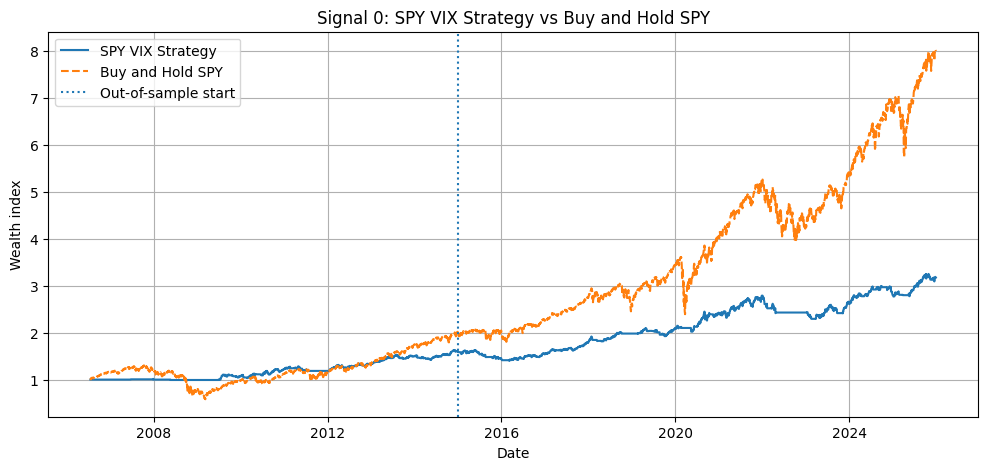

In [2]:
# ============================================================
# Signal 0: SPY / VIX term-structure strategy
# Parameter estimation and evaluation
# ============================================================

signal_0_tickers = [
    "SPY",
    "^VIX",
    "^VIX3M"
]

signal_0_start_date = "2004-01-01"
signal_0_end_date = "2025-12-31"

signal_0_in_sample_start = "2006-07-17"
signal_0_in_sample_end = "2014-12-31"

signal_0_out_sample_start = "2015-01-01"
signal_0_out_sample_end = "2025-12-31"

df_signal_0_prices, _ = module.download_stock_price_data(
    signal_0_tickers,
    signal_0_start_date,
    signal_0_end_date
)

spy_series = df_signal_0_prices["SPY"]
vix_series = df_signal_0_prices["^VIX"]
vix3m_series = df_signal_0_prices["^VIX3M"]

spy_in_sample = spy_series.loc[
    signal_0_in_sample_start:signal_0_in_sample_end
]

spy_out_sample = spy_series.loc[
    signal_0_out_sample_start:signal_0_out_sample_end
]

spy_full_sample = spy_series.loc[
    signal_0_in_sample_start:signal_0_out_sample_end
]

ratio_thresholds = [0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15]
momentum_windows = [63, 126, 168, 210, 252]
momentum_thresholds = [-0.05, -0.025, 0.00, 0.025, 0.05]

calibration_results = []

for ratio_threshold in ratio_thresholds:
    for momentum_window in momentum_windows:
        for momentum_threshold in momentum_thresholds:

            signal_frame = module.vix_term_structure_signal(
                target_series=spy_in_sample,
                vix_series=vix_series,
                vix3m_series=vix3m_series,
                ratio_threshold=ratio_threshold,
                momentum_window=momentum_window,
                momentum_threshold=momentum_threshold
            )

            stats, _, _ = evaluate_candidate(
                spy_in_sample,
                signal_frame
            )

            stats["Ratio Threshold"] = ratio_threshold
            stats["Momentum Window"] = momentum_window
            stats["Momentum Threshold"] = momentum_threshold

            calibration_results.append(stats)

df_signal_0_results = pd.DataFrame(calibration_results)

df_signal_0_results = df_signal_0_results[
    [
        "Ratio Threshold",
        "Momentum Window",
        "Momentum Threshold",
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Max Drawdown",
        "Active Share",
        "Number of Trades"
    ]
]

df_signal_0_results = df_signal_0_results.sort_values(
    by="Sharpe Ratio",
    ascending=False
).reset_index(drop=True)

df_signal_0_results["Rank"] = np.arange(1, len(df_signal_0_results) + 1)

print("Signal 0 top 10 parameter combinations:")
display(df_signal_0_results.head(10).round(4))

best_signal_0 = df_signal_0_results.iloc[0]

signal_0_ratio_threshold = float(best_signal_0["Ratio Threshold"])
signal_0_momentum_window = int(best_signal_0["Momentum Window"])
signal_0_momentum_threshold = float(best_signal_0["Momentum Threshold"])

print("Selected Signal 0 parameters:")
print("Ratio threshold:", signal_0_ratio_threshold)
print("Momentum window:", signal_0_momentum_window)
print("Momentum threshold:", signal_0_momentum_threshold)


def make_signal_0(price_series):
    return module.vix_term_structure_signal(
        target_series=price_series,
        vix_series=vix_series,
        vix3m_series=vix3m_series,
        ratio_threshold=signal_0_ratio_threshold,
        momentum_window=signal_0_momentum_window,
        momentum_threshold=signal_0_momentum_threshold
    )


signal_0_in = make_signal_0(spy_in_sample)
signal_0_out = make_signal_0(spy_out_sample)
signal_0_full = make_signal_0(spy_full_sample)

strategy_0_in, buy_hold_0_in, stats_0_in, bh_0_in = evaluate_signal_curve(
    spy_in_sample,
    signal_0_in
)

strategy_0_out, buy_hold_0_out, stats_0_out, bh_0_out = evaluate_signal_curve(
    spy_out_sample,
    signal_0_out
)

strategy_0_full, buy_hold_0_full, stats_0_full, bh_0_full = evaluate_signal_curve(
    spy_full_sample,
    signal_0_full
)

df_signal_0_statistics = build_statistics_table(
    strategy_name="SPY VIX Strategy",
    buy_hold_name="Buy and Hold SPY",
    in_sample_stats=stats_0_in,
    buy_hold_in_sample_stats=bh_0_in,
    out_sample_stats=stats_0_out,
    buy_hold_out_sample_stats=bh_0_out,
    full_sample_stats=stats_0_full,
    buy_hold_full_sample_stats=bh_0_full
)

display(df_signal_0_statistics)

plot_strategy_vs_buy_hold(
    strategy_curve=strategy_0_full,
    buy_hold_curve=buy_hold_0_full,
    title="Signal 0: SPY VIX Strategy vs Buy and Hold SPY",
    strategy_label="SPY VIX Strategy",
    buy_hold_label="Buy and Hold SPY",
    out_of_sample_start=signal_0_out_sample_start
)

## Results

The in-sample grid search ranks the parameter combination with a VIX3M/VIX threshold of **1.10**, a **168-day** SPY momentum window and a momentum threshold of **-2.5%** as the best setting by Sharpe ratio. The selected parameters therefore come from the empirical calibration step rather than from an arbitrary manual choice.

Out of sample, the SPY / VIX strategy produces a lower annualized return than buy-and-hold SPY, but it also has much lower volatility and a smaller maximum drawdown. The Sharpe ratio is higher for the strategy (**0.8882**) than for buy-and-hold SPY (**0.8001**), while the maximum drawdown improves from **-33.72%** to **-17.70%**. This suggests that Signal 0 mainly adds value through risk reduction rather than through maximizing raw return.

# Signal 1: Oil / Energy Relative-Strength Strategy

This signal trades **XLE** (Energy Select Sector SPDR Fund). XLE is an energy-sector equity ETF, so it represents energy companies rather than crude oil itself. Crude-oil futures and SPY are only used as information variables in this rule; they are never traded by the strategy.

## Economic motivation and literature

The economic idea behind this signal is that energy stocks should perform better when both the energy sector itself and the oil market are in a supportive condition. Since many companies in the energy sector are connected to oil and gas production, refining, transportation, or energy services, crude oil prices can contain useful information about the business environment of these firms.

Sadorsky (2001, p. 17) finds that crude oil prices have a large and significant impact on Canadian oil and gas stock returns. He also reports that an increase in the oil price factor increases returns to Canadian oil and gas stocks. This supports the idea that crude oil can be used as an information variable for energy-sector equities.

At the same time, oil prices alone are not enough to justify buying XLE. XLE is still an equity ETF, not a commodity future. Its return also depends on the broad stock market, investor sentiment, company earnings, costs, balance sheets, and sector rotation. Therefore, this strategy does not simply buy XLE whenever oil prices increase. Instead, oil momentum is only one filter within a broader signal.

The trend-following part of the strategy is motivated by the momentum literature. Moskowitz, Ooi and Pedersen (2012, p. 228) document significant time-series momentum in equity-index, currency, commodity and bond futures. They find return persistence over horizons of approximately one to twelve months. This supports the use of past returns as a signal for future returns.

The strategy combines two ideas. First, crude oil is used as a state variable for the energy sector. Second, XLE itself must show positive trend and momentum confirmation. In addition, the XLE/SPY ratio is used to check whether energy stocks are holding up relative to the broad US equity market.

The relative-strength part is important because XLE can rise simply because the whole equity market is rising. By comparing XLE with SPY, the signal checks whether energy equities are doing reasonably well compared with the overall market.

## Signal conditions

For any price series $P$, momentum over $n$ trading days is:

$$
M_t^{P}(n) = \frac{P_t}{P_{t-n}} - 1
$$

The calibrated XLE trend and absolute-momentum conditions are:

$$
XLE_t > MA_t^{XLE}(200)
$$

$$
M_t^{XLE}(210) > 0
$$

Crude-oil momentum must satisfy:

$$
M_t^{Oil}(126) > -0.05
$$

The relative-strength ratio is:

$$
RS_t^{XLE/SPY} = \frac{XLE_t}{SPY_t}
$$

and the relative-strength momentum is:

$$
M_t^{RS}(21) = \frac{RS_t^{XLE/SPY}}{RS_{t-21}^{XLE/SPY}} - 1
$$

with the calibrated requirement:

$$
M_t^{RS}(21) > -0.025
$$

The final rule is therefore:

$$
S_t^{XLE} =
\begin{cases}
1, & \text{if all trend, oil momentum and relative-strength conditions are satisfied} \\
0, & \text{otherwise}
\end{cases}
$$

This means the strategy buys XLE only when the energy sector, crude-oil information and relative strength point in a supportive direction.

## Bibliography

* Sadorsky, P. (2001). Risk factors in stock returns of Canadian oil and gas companies. *Energy Economics, 23*(1), 17-28.
* Elyasiani, E., Mansur, I., & Odusami, B. (2011). Oil price shocks and industry stock returns. *Energy Economics, 33*(5), 966-974.
* Moskowitz, T. J., Ooi, Y. H., & Pedersen, L. H. (2012). Time series momentum. *Journal of Financial Economics, 104*(2), 228-250.
* Hurst, B., Ooi, Y. H., & Pedersen, L. H. (2017). A century of evidence on trend-following investing. AQR Capital Management.


Signal 1 top 10 parameter combinations:


,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Active Share,Number of Trades,Trend Window,Oil Momentum Window,Oil Momentum Threshold,Target Momentum Window,Target Momentum Threshold,Relative Strength Window,Relative Strength Threshold,Calibration Score,Rank
0,0.0898,0.1438,0.6701,-0.2206,0.4411,182.0,200,126,-0.05,210,0.000,21,-0.025,0.7598,1
1,0.0874,0.1415,0.6630,-0.2444,0.4133,146.0,150,126,-0.05,210,0.025,63,-0.025,0.7504,2
2,0.0848,0.1411,0.6475,-0.2206,0.4358,192.0,150,126,-0.05,210,0.000,21,-0.025,0.7322,3
3,0.0845,0.1419,0.6430,-0.2444,0.4191,156.0,150,126,-0.05,210,0.000,63,-0.025,0.7275,4
4,0.0836,0.1405,0.6423,-0.2468,0.4283,176.0,150,126,-0.05,210,0.025,21,-0.025,0.7260,5
5,0.0848,0.1434,0.6393,-0.2345,0.4344,166.0,200,126,-0.05,210,0.025,21,-0.025,0.7240,6
6,0.0830,0.1406,0.6374,-0.2444,0.4086,148.0,150,126,-0.05,210,0.050,63,-0.025,0.7204,7
7,0.0800,0.1392,0.6228,-0.2224,0.4230,180.0,150,126,-0.05,210,0.050,21,-0.025,0.7029,8
8,0.0798,0.1396,0.6203,-0.2363,0.4019,140.0,150,126,-0.05,210,0.075,63,-0.025,0.7001,9
9,0.0789,0.1386,0.6172,-0.2461,0.3644,92.0,150,126,-0.05,210,0.025,126,0.000,0.6961,10


Signal 1 selection method:
Best calibration score after robustness filters
Selected Signal 1 parameters:
Trend window: 200
Oil momentum window: 126
Oil momentum threshold: -0.05
Target momentum window: 210
Target momentum threshold: 0.0
Relative strength window: 21
Relative strength threshold: -0.025


,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
Oil Energy Strategy In-Sample,0.0898,0.1438,0.6701,-0.2206
Buy and Hold XLE In-Sample,0.0800,0.2840,0.4136,-0.5736
Oil Energy Strategy Out-of-Sample,0.0449,0.1350,0.3935,-0.4228
Buy and Hold XLE Out-of-Sample,0.0519,0.2925,0.3203,-0.6681
Oil Energy Strategy Full Sample,0.0701,0.1401,0.5538,-0.4228
Buy and Hold XLE Full Sample,0.0679,0.2877,0.3730,-0.7126


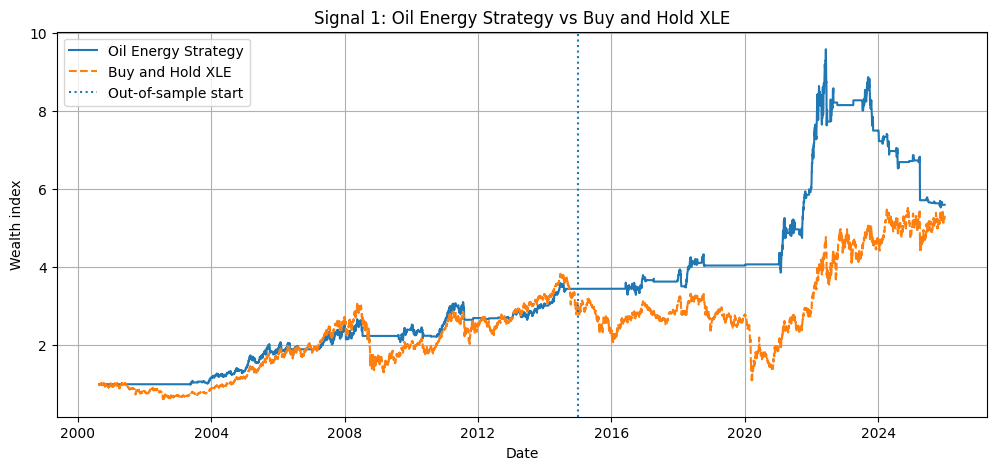

In [3]:
# ============================================================
# Signal 1: Oil / Energy relative-strength strategy
# ============================================================

signal_1_tickers = ["XLE", "CL=F", "SPY"]

signal_1_start_date = "2000-01-01"
signal_1_end_date = "2025-12-31"

signal_1_in_sample_start = "2000-01-01"
signal_1_in_sample_end = "2014-12-31"

signal_1_out_sample_start = "2015-01-01"
signal_1_out_sample_end = "2025-12-31"

df_signal_1_prices, _ = module.download_stock_price_data(
    signal_1_tickers,
    signal_1_start_date,
    signal_1_end_date
)

xle_series = df_signal_1_prices["XLE"]
oil_series = df_signal_1_prices["CL=F"]
market_series = df_signal_1_prices["SPY"]

xle_in_sample = xle_series.loc[
    signal_1_in_sample_start:signal_1_in_sample_end
]

oil_in_sample = oil_series.loc[
    signal_1_in_sample_start:signal_1_in_sample_end
]

market_in_sample = market_series.loc[
    signal_1_in_sample_start:signal_1_in_sample_end
]

xle_out_sample = xle_series.loc[
    signal_1_out_sample_start:signal_1_out_sample_end
]

oil_out_sample = oil_series.loc[
    signal_1_out_sample_start:signal_1_out_sample_end
]

market_out_sample = market_series.loc[
    signal_1_out_sample_start:signal_1_out_sample_end
]

xle_full_sample = xle_series.loc[
    signal_1_in_sample_start:signal_1_out_sample_end
]

oil_full_sample = oil_series.loc[
    signal_1_in_sample_start:signal_1_out_sample_end
]

market_full_sample = market_series.loc[
    signal_1_in_sample_start:signal_1_out_sample_end
]


# ============================================================
# Parameter grid
# ============================================================

trend_windows = [100, 150, 200, 250]

oil_momentum_windows = [21, 63, 126]
oil_momentum_thresholds = [-0.05, 0.00, 0.05, 0.10]

target_momentum_windows = [63, 126, 168, 210]
target_momentum_thresholds = [0.00, 0.025, 0.05, 0.075]

relative_strength_windows = [21, 63, 126]
relative_strength_thresholds = [-0.025, 0.00, 0.025, 0.05]


# ============================================================
# In-sample calibration
# ============================================================

calibration_results = []

for trend_window in trend_windows:
    for oil_momentum_window in oil_momentum_windows:
        for oil_momentum_threshold in oil_momentum_thresholds:
            for target_momentum_window in target_momentum_windows:
                for target_momentum_threshold in target_momentum_thresholds:
                    for relative_strength_window in relative_strength_windows:
                        for relative_strength_threshold in relative_strength_thresholds:

                            signal_frame = module.oil_energy_relative_strength_signal(
                                target_series=xle_in_sample,
                                oil_series=oil_in_sample,
                                market_series=market_in_sample,
                                trend_window=trend_window,
                                oil_momentum_window=oil_momentum_window,
                                oil_momentum_threshold=oil_momentum_threshold,
                                target_momentum_window=target_momentum_window,
                                target_momentum_threshold=target_momentum_threshold,
                                relative_strength_window=relative_strength_window,
                                relative_strength_threshold=relative_strength_threshold
                            )

                            stats, _, _ = evaluate_candidate(
                                xle_in_sample,
                                signal_frame
                            )

                            stats["Trend Window"] = trend_window
                            stats["Oil Momentum Window"] = oil_momentum_window
                            stats["Oil Momentum Threshold"] = oil_momentum_threshold
                            stats["Target Momentum Window"] = target_momentum_window
                            stats["Target Momentum Threshold"] = target_momentum_threshold
                            stats["Relative Strength Window"] = relative_strength_window
                            stats["Relative Strength Threshold"] = relative_strength_threshold

                            calibration_results.append(stats)


df_signal_1_results = pd.DataFrame(calibration_results)

df_signal_1_results["Calibration Score"] = (
    df_signal_1_results["Sharpe Ratio"]
    + df_signal_1_results["Annualized Return"]
)

df_signal_1_results = df_signal_1_results.sort_values(
    by="Calibration Score",
    ascending=False
).reset_index(drop=True)

df_signal_1_results["Rank"] = np.arange(
    1,
    len(df_signal_1_results) + 1
)

print("Signal 1 top 10 parameter combinations:")
display(df_signal_1_results.head(10).round(4))


# ============================================================
# Robustness filters
# ============================================================

df_signal_1_reasonable = df_signal_1_results[
    (df_signal_1_results["Active Share"] >= 0.20)
    & (df_signal_1_results["Active Share"] <= 0.95)
    & (df_signal_1_results["Max Drawdown"] >= -0.50)
    & (df_signal_1_results["Number of Trades"] <= 700)
].copy()

if len(df_signal_1_reasonable) > 0:
    best_signal_1 = df_signal_1_reasonable.iloc[0]
    selection_method_1 = "Best calibration score after robustness filters"
else:
    best_signal_1 = df_signal_1_results.iloc[0]
    selection_method_1 = "Best calibration score without filters"

print("Signal 1 selection method:")
print(selection_method_1)


# ============================================================
# Selected parameters
# ============================================================

signal_1_trend_window = int(best_signal_1["Trend Window"])

signal_1_oil_momentum_window = int(best_signal_1["Oil Momentum Window"])
signal_1_oil_momentum_threshold = float(best_signal_1["Oil Momentum Threshold"])

signal_1_target_momentum_window = int(best_signal_1["Target Momentum Window"])
signal_1_target_momentum_threshold = float(best_signal_1["Target Momentum Threshold"])

signal_1_relative_strength_window = int(best_signal_1["Relative Strength Window"])
signal_1_relative_strength_threshold = float(best_signal_1["Relative Strength Threshold"])

print("Selected Signal 1 parameters:")
print("Trend window:", signal_1_trend_window)
print("Oil momentum window:", signal_1_oil_momentum_window)
print("Oil momentum threshold:", signal_1_oil_momentum_threshold)
print("Target momentum window:", signal_1_target_momentum_window)
print("Target momentum threshold:", signal_1_target_momentum_threshold)
print("Relative strength window:", signal_1_relative_strength_window)
print("Relative strength threshold:", signal_1_relative_strength_threshold)


# ============================================================
# Evaluation with selected parameters
# ============================================================

def make_signal_1(price_series, oil_info_series, market_info_series):

    return module.oil_energy_relative_strength_signal(
        target_series=price_series,
        oil_series=oil_info_series,
        market_series=market_info_series,
        trend_window=signal_1_trend_window,
        oil_momentum_window=signal_1_oil_momentum_window,
        oil_momentum_threshold=signal_1_oil_momentum_threshold,
        target_momentum_window=signal_1_target_momentum_window,
        target_momentum_threshold=signal_1_target_momentum_threshold,
        relative_strength_window=signal_1_relative_strength_window,
        relative_strength_threshold=signal_1_relative_strength_threshold
    )


signal_1_in = make_signal_1(
    xle_in_sample,
    oil_in_sample,
    market_in_sample
)

signal_1_out = make_signal_1(
    xle_out_sample,
    oil_out_sample,
    market_out_sample
)

signal_1_full = make_signal_1(
    xle_full_sample,
    oil_full_sample,
    market_full_sample
)


strategy_1_in, buy_hold_1_in, stats_1_in, bh_1_in = evaluate_signal_curve(
    xle_in_sample,
    signal_1_in
)

strategy_1_out, buy_hold_1_out, stats_1_out, bh_1_out = evaluate_signal_curve(
    xle_out_sample,
    signal_1_out
)

strategy_1_full, buy_hold_1_full, stats_1_full, bh_1_full = evaluate_signal_curve(
    xle_full_sample,
    signal_1_full
)


df_signal_1_statistics = build_statistics_table(
    strategy_name="Oil Energy Strategy",
    buy_hold_name="Buy and Hold XLE",
    in_sample_stats=stats_1_in,
    buy_hold_in_sample_stats=bh_1_in,
    out_sample_stats=stats_1_out,
    buy_hold_out_sample_stats=bh_1_out,
    full_sample_stats=stats_1_full,
    buy_hold_full_sample_stats=bh_1_full
)

display(df_signal_1_statistics)


plot_strategy_vs_buy_hold(
    strategy_curve=strategy_1_full,
    buy_hold_curve=buy_hold_1_full,
    title="Signal 1: Oil Energy Strategy vs Buy and Hold XLE",
    strategy_label="Oil Energy Strategy",
    buy_hold_label="Buy and Hold XLE",
    out_of_sample_start=signal_1_out_sample_start
)

## Results

The in-sample calibration shows that the XLE / Oil signal performs best when several filters are combined rather than relying only on crude-oil momentum. In-sample, the selected strategy achieves a Sharpe ratio of **0.6701**, compared with **0.4136** for buy-and-hold XLE. The maximum drawdown is also much lower at **-22.06%**, compared with **-57.36%** for buy-and-hold XLE.


Out of sample, the strategy again has a slightly lower annualized return than buy-and-hold XLE, but it strongly reduces volatility and drawdown. The Sharpe ratio improves from **0.3203** for buy-and-hold XLE to **0.3935** for the strategy. The maximum drawdown improves from **-66.81%** to **-42.28%**. Therefore, Signal 1 is useful mainly because it avoids some of the most severe downside periods in energy equities.

# Signal 2: Gold Safe-Haven Strategy

This signal trades **GLD** (SPDR Gold Shares ETF). TLT (iShares 20+ Year Treasury Bond ETF) is used only as an information variable and is never traded directly.

## Empirical Motivation for the Gold Signal

The Gold Signal is motivated by the empirical role of gold as an asset that can behave differently from equities and sector-based stock strategies. Since Signal 0 is based on SPY and volatility conditions, and Signal 1 is based on XLE and oil-related strength, gold adds a different return driver to the strategy set. Gold is often discussed in the literature as a potential hedge or safe-haven asset, especially during periods of financial uncertainty. However, the empirical evidence also suggests that gold should not simply be held permanently, because its safe-haven role can depend on the market environment.

For this reason, the signal uses a regime-based approach. The first condition requires GLD to trade above its long-term moving average. This trend filter is included to avoid holding gold during persistent downward trends. The second condition requires positive medium-term GLD momentum. This is motivated by empirical evidence on time-series momentum, which shows that assets with positive past returns can continue to perform well over intermediate horizons. The third condition uses TLT momentum as an information variable. TLT is not traded directly, but it provides information about the bond and interest-rate environment. If long-term Treasury bonds are strongly weak, the environment may be less supportive for defensive assets such as gold.

The parameters are not chosen arbitrarily. Different trend windows, GLD momentum windows, GLD momentum thresholds and TLT momentum thresholds are tested in the in-sample period. The selected parameter combination is then evaluated out of sample. This gives the Gold Signal an empirical basis and reduces the risk of choosing parameters only because they perform well over the full sample.

## Signal Conditions

The Gold Safe-Haven signal combines three conditions: a GLD trend filter, a GLD momentum filter, and a TLT momentum filter.

The GLD trend condition is:

$$
GLD_t > MA_t^{GLD}(100)
$$

where $MA_t^{GLD}(100)$ is the 100-day moving average of GLD.

The GLD momentum condition is:

$$
M_t^{GLD}(63) = \frac{GLD_t}{GLD_{t-63}} - 1
$$

with the calibrated requirement:

$$
M_t^{GLD}(63) > 0
$$

The TLT momentum condition is:

$$
M_t^{TLT}(63) = \frac{TLT_t}{TLT_{t-63}} - 1
$$

with the calibrated requirement:

$$
M_t^{TLT}(63) > -0.02
$$

The final signal is:

$$
S_t^{GLD} =
\begin{cases}
1, & \text{if } GLD_t > MA_t^{GLD}(100),\ M_t^{GLD}(63) > 0,\ \text{and } M_t^{TLT}(63) > -0.02 \\
0, & \text{otherwise}
\end{cases}
$$

This means that the strategy only holds GLD when gold is in a positive trend, gold has positive recent momentum, and the bond-market environment is not strongly negative. TLT is not traded directly; it is only used as an information variable.

## References

Baur, D. G. and Lucey, B. M. (2010). Gold as a hedge and a safe haven: An analysis of stocks, bonds and gold. *The Financial Review*, 45(2), 217-229.  
https://doi.org/10.1111/j.1540-6288.2010.00244.x

Baur, D. G. and McDermott, T. K. (2010). Is gold a safe haven? International evidence. *Journal of Banking & Finance*, 34(8), 1886-1898.  
https://doi.org/10.1016/j.jbankfin.2009.12.008

Moskowitz, T. J., Ooi, Y. H. and Pedersen, L. H. (2012). Time series momentum. *Journal of Financial Economics*, 104(2), 228-250.  
https://doi.org/10.1016/j.jfineco.2011.11.003

In [4]:
# ============================================================
# Signal 2: Gold Safe-Haven Strategy
# Step 1 — Download data
# ============================================================

# GLD launched in November 2004, TLT in July 2002.
# We start from 2005-01-01 so both series have a full year of history
# before the in-sample period begins.
signal_2_tickers = ["GLD", "TLT"]

signal_2_start_date = "2005-01-01"
signal_2_end_date   = "2025-12-31"

# In-sample: used ONLY for parameter calibration — never for evaluation
signal_2_in_sample_start  = "2005-01-01"
signal_2_in_sample_end    = "2014-12-31"

# Out-of-sample: held-out period — parameters are frozen before this starts
signal_2_out_sample_start = "2015-01-01"
signal_2_out_sample_end   = "2025-12-31"

df_signal_2_prices, _ = module.download_stock_price_data(
    signal_2_tickers,
    signal_2_start_date,
    signal_2_end_date
)

gld_series = df_signal_2_prices["GLD"]
tlt_series = df_signal_2_prices["TLT"]

# Slice in-sample / out-of-sample / full periods for GLD
# TLT is only an information variable so we keep the full series and
# let the signal function reindex it to match each GLD slice
gld_in_sample  = gld_series.loc[signal_2_in_sample_start  : signal_2_in_sample_end]
gld_out_sample = gld_series.loc[signal_2_out_sample_start : signal_2_out_sample_end]
gld_full       = gld_series.loc[signal_2_in_sample_start  : signal_2_out_sample_end]

print("GLD in-sample  :", gld_in_sample.index[0].date(), "to", gld_in_sample.index[-1].date())
print("GLD out-sample :", gld_out_sample.index[0].date(), "to", gld_out_sample.index[-1].date())
print("GLD full       :", gld_full.index[0].date(), "to", gld_full.index[-1].date())

GLD in-sample  : 2005-01-03 to 2014-12-31
GLD out-sample : 2015-01-02 to 2025-12-30
GLD full       : 2005-01-03 to 2025-12-30


In [5]:
# ============================================================
# Signal 2: In-sample parameter grid search
# ALL calibration uses gld_in_sample only — no future data
# ============================================================

# Parameter grids to search
trend_windows          = [100, 150, 200, 250]
momentum_windows       = [63, 126, 168, 252]    # 3 / 6 / 8 / 12 months
gld_momentum_thresholds = [-0.02, 0.0, 0.02, 0.05]
tlt_momentum_thresholds = [-0.02, 0.0, 0.02, 0.05]

calibration_results = []

for trend_w in trend_windows:
    for mom_w in momentum_windows:
        for gld_thr in gld_momentum_thresholds:
            for tlt_thr in tlt_momentum_thresholds:

                # Build signal on IN-SAMPLE data only
                sf = module.gold_safe_haven_signal(
                    gld_series              = gld_in_sample,
                    tlt_series              = tlt_series,   # full series; function reindexes
                    trend_window            = trend_w,
                    momentum_window         = mom_w,
                    gld_momentum_threshold  = gld_thr,
                    tlt_momentum_threshold  = tlt_thr
                )

                # evaluate_candidate applies the 1-day execution delay internally
                stats, _, _ = evaluate_candidate(gld_in_sample, sf)

                stats["Trend Window"]     = trend_w
                stats["Momentum Window"]  = mom_w
                stats["GLD Threshold"]    = gld_thr
                stats["TLT Threshold"]    = tlt_thr
                calibration_results.append(stats)

df_signal_2_results = pd.DataFrame(calibration_results)

# Score = Sharpe + Return, same methodology as Signal 1
df_signal_2_results["Calibration Score"] = (
    df_signal_2_results["Sharpe Ratio"]
    + df_signal_2_results["Annualized Return"]
)

df_signal_2_results = df_signal_2_results.sort_values(
    by="Calibration Score", ascending=False
).reset_index(drop=True)

print("Signal 2 top 10 parameter combinations (in-sample):")
display(df_signal_2_results.head(10).round(4))

# Apply same robustness filters used for Signals 1 and 2
df_signal_2_reasonable = df_signal_2_results[
    (df_signal_2_results["Active Share"]     >= 0.10)
    & (df_signal_2_results["Active Share"]   <= 0.90)
    & (df_signal_2_results["Max Drawdown"]   >= -0.45)
    & (df_signal_2_results["Number of Trades"] <= 500)
].copy()

if len(df_signal_2_reasonable) > 0:
    best_signal_2 = df_signal_2_reasonable.iloc[0]
    selection_method_2 = "Best calibration score after robustness filters"
else:
    best_signal_2 = df_signal_2_results.iloc[0]
    selection_method_2 = "Best calibration score without filters"

print("\nSignal 2 selection method:", selection_method_2)

# Extract best parameters
signal_2_trend_window           = int(best_signal_2["Trend Window"])
signal_2_momentum_window        = int(best_signal_2["Momentum Window"])
signal_2_gld_momentum_threshold = float(best_signal_2["GLD Threshold"])
signal_2_tlt_momentum_threshold = float(best_signal_2["TLT Threshold"])

print("\nSelected Signal 2 parameters:")
print("  Trend window          :", signal_2_trend_window)
print("  Momentum window       :", signal_2_momentum_window)
print("  GLD momentum threshold:", signal_2_gld_momentum_threshold)
print("  TLT momentum threshold:", signal_2_tlt_momentum_threshold)

Signal 2 top 10 parameter combinations (in-sample):


,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Active Share,Number of Trades,Trend Window,Momentum Window,GLD Threshold,TLT Threshold,Calibration Score
0,0.0962,0.1220,0.8144,-0.1725,0.4005,152.0,100,63,0.00,-0.02,0.9106
1,0.0952,0.1252,0.7891,-0.2051,0.4203,142.0,150,63,-0.02,-0.02,0.8843
2,0.0820,0.1068,0.7915,-0.1463,0.2956,124.0,100,63,0.02,0.00,0.8735
3,0.0923,0.1242,0.7731,-0.1757,0.4259,154.0,100,63,-0.02,-0.02,0.8654
4,0.0807,0.1110,0.7550,-0.1514,0.3381,136.0,100,63,0.00,0.00,0.8357
5,0.0813,0.1123,0.7529,-0.1785,0.3572,148.0,100,63,-0.02,0.00,0.8343
6,0.0843,0.1175,0.7480,-0.2045,0.3488,146.0,100,63,0.02,-0.02,0.8323
7,0.0797,0.1132,0.7342,-0.1913,0.3496,140.0,150,63,-0.02,0.00,0.8139
8,0.0719,0.1006,0.7405,-0.1463,0.2332,108.0,100,63,0.05,0.00,0.8124
9,0.0848,0.1225,0.7261,-0.2136,0.3913,144.0,150,63,0.00,-0.02,0.8110



Signal 2 selection method: Best calibration score after robustness filters

Selected Signal 2 parameters:
  Trend window          : 100
  Momentum window       : 63
  GLD momentum threshold: 0.0
  TLT momentum threshold: -0.02


Signal 2 — Performance Statistics


,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
GLD Safe-Haven Strategy In-Sample,0.0962,0.1220,0.8144,-0.1725
Buy and Hold GLD In-Sample,0.1013,0.2032,0.5766,-0.4052
GLD Safe-Haven Strategy Out-of-Sample,0.0718,0.1058,0.7083,-0.1714
Buy and Hold GLD Out-of-Sample,0.1199,0.1469,0.8446,-0.2200
GLD Safe-Haven Strategy Full Sample,0.0803,0.1144,0.7327,-0.1928
Buy and Hold GLD Full Sample,0.1112,0.1760,0.6874,-0.4556


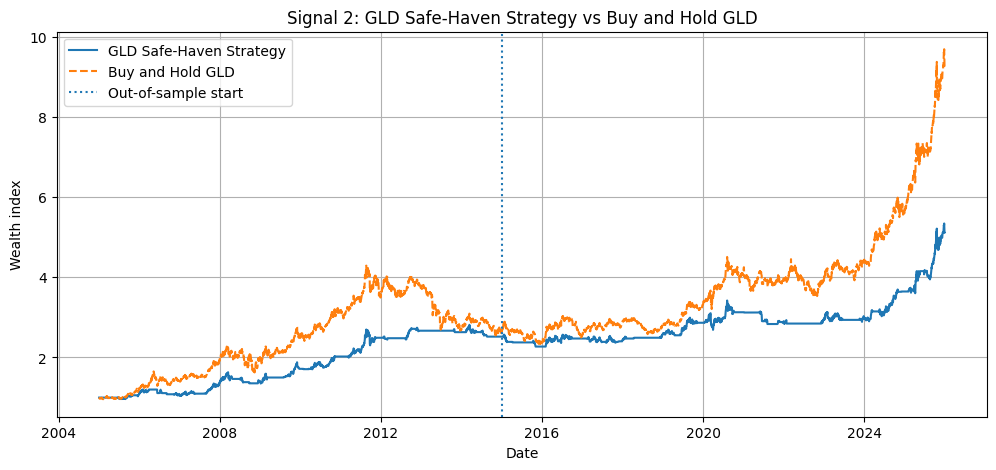

In [6]:
# ============================================================
# Signal 2: Evaluate with selected parameters
# in-sample / out-of-sample / full sample
# ============================================================

def make_signal_2(price_series):
    """Build the gold safe-haven signal for any GLD price slice."""
    return module.gold_safe_haven_signal(
        gld_series              = price_series,
        tlt_series              = tlt_series,
        trend_window            = signal_2_trend_window,
        momentum_window         = signal_2_momentum_window,
        gld_momentum_threshold  = signal_2_gld_momentum_threshold,
        tlt_momentum_threshold  = signal_2_tlt_momentum_threshold
    )


# Build signals for each period
# NOTE: parameters were selected on in-sample only — no look-ahead
signal_2_in  = make_signal_2(gld_in_sample)
signal_2_out = make_signal_2(gld_out_sample)
signal_2_full = make_signal_2(gld_full)

# evaluate_signal_curve applies apply_execution_delay(shift=1) internally,
# so the signal at close t earns the return from t+1 to t+2 — no look-ahead
strategy_2_in,   bh_2_in,   stats_2_in,   bh_stats_2_in   = evaluate_signal_curve(gld_in_sample,  signal_2_in)
strategy_2_out,  bh_2_out,  stats_2_out,  bh_stats_2_out  = evaluate_signal_curve(gld_out_sample, signal_2_out)
strategy_2_full, bh_2_full, stats_2_full, bh_stats_2_full = evaluate_signal_curve(gld_full,       signal_2_full)

df_signal_2_statistics = build_statistics_table(
    strategy_name            = "GLD Safe-Haven Strategy",
    buy_hold_name            = "Buy and Hold GLD",
    in_sample_stats          = stats_2_in,
    buy_hold_in_sample_stats = bh_stats_2_in,
    out_sample_stats         = stats_2_out,
    buy_hold_out_sample_stats= bh_stats_2_out,
    full_sample_stats        = stats_2_full,
    buy_hold_full_sample_stats= bh_stats_2_full
)

print("Signal 2 — Performance Statistics")
display(df_signal_2_statistics)

plot_strategy_vs_buy_hold(
    strategy_curve     = strategy_2_full,
    buy_hold_curve     = bh_2_full,
    title              = "Signal 2: GLD Safe-Haven Strategy vs Buy and Hold GLD",
    strategy_label     = "GLD Safe-Haven Strategy",
    buy_hold_label     = "Buy and Hold GLD",
    out_of_sample_start= signal_2_out_sample_start
)

## Results

The in-sample calibration gives the Gold Safe-Haven signal the strongest risk-adjusted performance among the tested gold parameter combinations. In-sample, the strategy achieves a Sharpe ratio of **0.8144**, compared with **0.5766** for buy-and-hold GLD. The maximum drawdown is also much smaller at **-17.25%**, compared with **-40.52%** for buy-and-hold GLD.

Out of sample, buy-and-hold GLD has the higher annualized return and Sharpe ratio. However, the strategy has lower volatility and a smaller drawdown. The maximum drawdown improves from **-22.00%** for buy-and-hold GLD to **-17.14%** for the strategy. This indicates that the Gold signal is not designed to fully replace buy-and-hold gold in strong gold bull markets. Instead, it acts as a risk-controlled gold exposure that adds a different return driver to the SPY and XLE signals.

# Cross-Signal Comparison

This section compares the three final strategies out of sample. Each signal trades a different underlying asset, so the main comparison is not one single combined wealth curve. Instead, the comparison focuses on risk-adjusted and normalized statistics:

- **Sharpe ratio:** return per unit of volatility.
- **Maximum drawdown:** worst peak-to-trough loss.
- **Strategy vs buy-and-hold:** each signal is compared with passive exposure to its own ETF.

The key question is whether each signal improves the risk-return profile relative to simply holding the same asset.

In [7]:
# ============================================================
# Cross-signal comparison: out-of-sample statistics table
# ============================================================

comparison_rows = [
    ("S0 SPY VIX Strategy", stats_0_out),
    ("S0 Buy & Hold SPY", bh_0_out),
    ("S1 XLE Oil Strategy", stats_1_out),
    ("S1 Buy & Hold XLE", bh_1_out),
    ("S2 GLD Safe-Haven Strategy", stats_2_out),
    ("S2 Buy & Hold GLD", bh_stats_2_out),
]

df_comparison = pd.DataFrame(
    {label: stats for label, stats in comparison_rows}
).T[
    [
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Max Drawdown"
    ]
]

print("Out-of-sample comparison: strategy vs buy-and-hold benchmark")
display(df_comparison.round(4))

Out-of-sample comparison: strategy vs buy-and-hold benchmark


,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
S0 SPY VIX Strategy,0.0714,0.0814,0.8882,-0.1770
S0 Buy & Hold SPY,0.1343,0.1772,0.8001,-0.3372
S1 XLE Oil Strategy,0.0449,0.1350,0.3935,-0.4228
S1 Buy & Hold XLE,0.0519,0.2925,0.3203,-0.6681
S2 GLD Safe-Haven Strategy,0.0718,0.1058,0.7083,-0.1714
S2 Buy & Hold GLD,0.1199,0.1469,0.8446,-0.2200


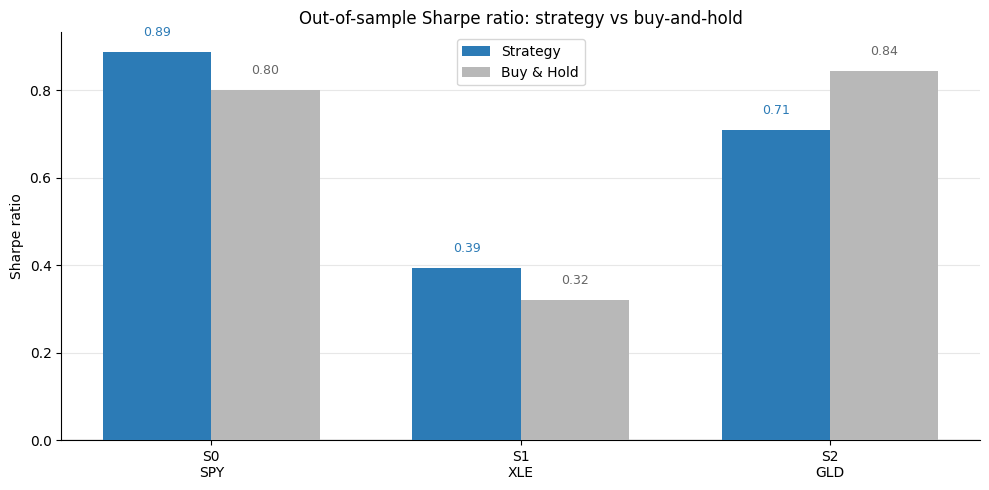

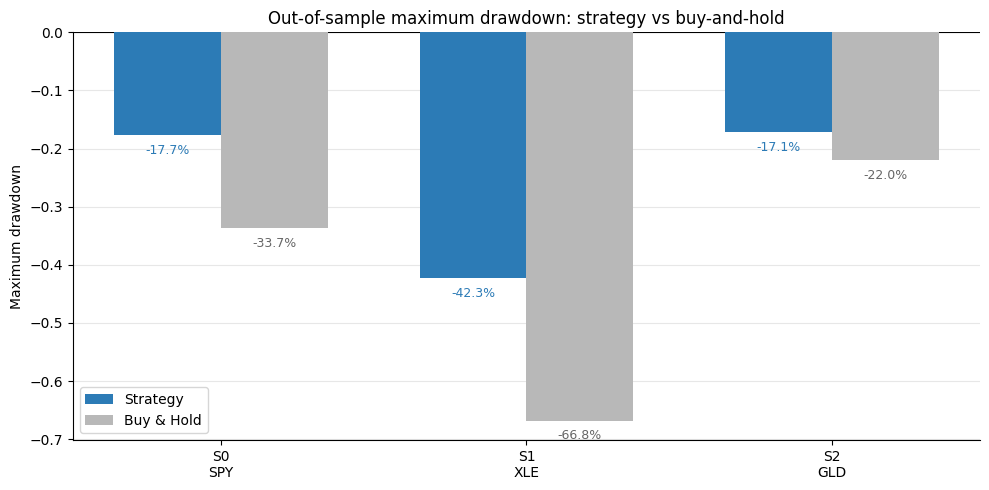

In [8]:
# ============================================================
# Cross-signal visualisations: Sharpe ratio and max drawdown
# ============================================================

strategy_colour = "#2c7bb6"
benchmark_colour = "#b8b8b8"

signal_labels = ["S0\nSPY", "S1\nXLE", "S2\nGLD"]
x = np.arange(len(signal_labels))
width = 0.35

strategy_sharpes = [
    stats_0_out["Sharpe Ratio"],
    stats_1_out["Sharpe Ratio"],
    stats_2_out["Sharpe Ratio"],
]
benchmark_sharpes = [
    bh_0_out["Sharpe Ratio"],
    bh_1_out["Sharpe Ratio"],
    bh_stats_2_out["Sharpe Ratio"],
]

fig, ax = plt.subplots(figsize=(10, 5))

bars_strategy = ax.bar(
    x - width / 2,
    strategy_sharpes,
    width,
    color=strategy_colour,
    label="Strategy",
    zorder=3
)
bars_benchmark = ax.bar(
    x + width / 2,
    benchmark_sharpes,
    width,
    color=benchmark_colour,
    label="Buy & Hold",
    zorder=3
)

for bars, colour in [(bars_strategy, strategy_colour), (bars_benchmark, "#666666")]:
    for bar in bars:
        h = bar.get_height()
        offset = 0.03 if h >= 0 else -0.08
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + offset,
            f"{h:.2f}",
            ha="center",
            va="bottom" if h >= 0 else "top",
            fontsize=9,
            color=colour
        )

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(signal_labels)
ax.set_ylabel("Sharpe ratio")
ax.set_title("Out-of-sample Sharpe ratio: strategy vs buy-and-hold")
ax.legend()
ax.grid(axis="y", alpha=0.3, zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

strategy_drawdowns = [
    stats_0_out["Max Drawdown"],
    stats_1_out["Max Drawdown"],
    stats_2_out["Max Drawdown"],
]
benchmark_drawdowns = [
    bh_0_out["Max Drawdown"],
    bh_1_out["Max Drawdown"],
    bh_stats_2_out["Max Drawdown"],
]

fig, ax = plt.subplots(figsize=(10, 5))

bars_strategy = ax.bar(
    x - width / 2,
    strategy_drawdowns,
    width,
    color=strategy_colour,
    label="Strategy",
    zorder=3
)
bars_benchmark = ax.bar(
    x + width / 2,
    benchmark_drawdowns,
    width,
    color=benchmark_colour,
    label="Buy & Hold",
    zorder=3
)

for bars, colour in [(bars_strategy, strategy_colour), (bars_benchmark, "#666666")]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h - 0.015,
            f"{h:.1%}",
            ha="center",
            va="top",
            fontsize=9,
            color=colour
        )

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(signal_labels)
ax.set_ylabel("Maximum drawdown")
ax.set_title("Out-of-sample maximum drawdown: strategy vs buy-and-hold")
ax.legend()
ax.grid(axis="y", alpha=0.3, zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

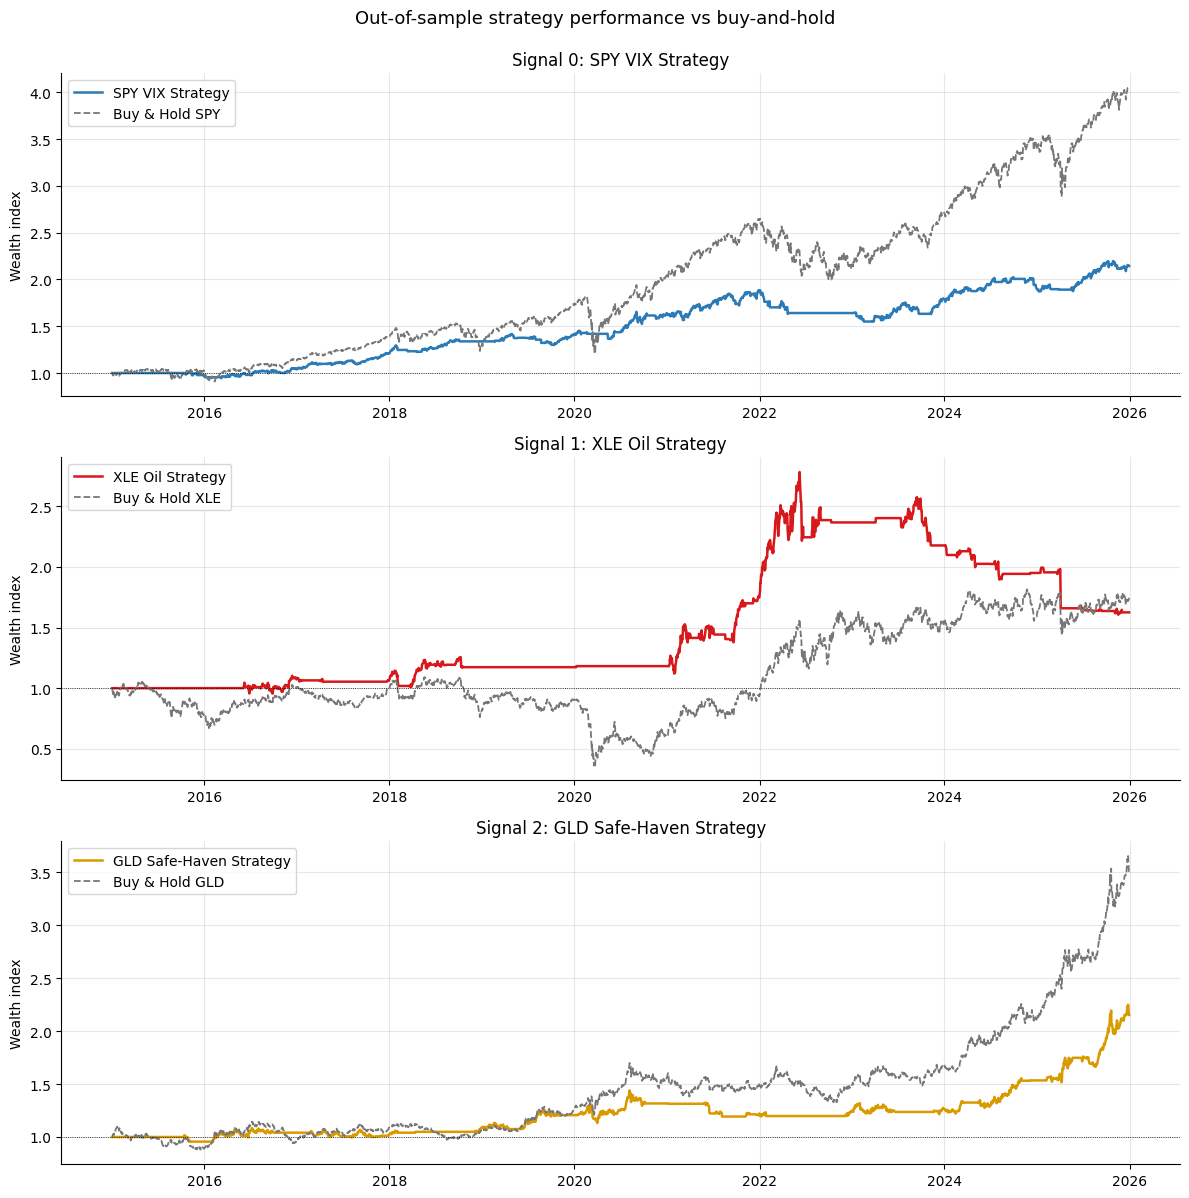

In [9]:
# ============================================================
# Out-of-sample wealth curves for all three final signals
# ============================================================

panels = [
    (
        "Signal 0: SPY VIX Strategy",
        strategy_0_out,
        buy_hold_0_out,
        "SPY VIX Strategy",
        "Buy & Hold SPY",
        "#2c7bb6"
    ),
    (
        "Signal 1: XLE Oil Strategy",
        strategy_1_out,
        buy_hold_1_out,
        "XLE Oil Strategy",
        "Buy & Hold XLE",
        "#d7191c"
    ),
    (
        "Signal 2: GLD Safe-Haven Strategy",
        strategy_2_out,
        bh_2_out,
        "GLD Safe-Haven Strategy",
        "Buy & Hold GLD",
        "#d99a00"
    ),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=False)
fig.suptitle(
    "Out-of-sample strategy performance vs buy-and-hold",
    fontsize=13,
    y=0.995
)

for ax, (title, strategy_curve, benchmark_curve, strategy_label, benchmark_label, colour) in zip(axes, panels):
    ax.plot(
        strategy_curve.index,
        strategy_curve.to_numpy(dtype=float),
        label=strategy_label,
        color=colour,
        linewidth=1.8
    )
    ax.plot(
        benchmark_curve.index,
        benchmark_curve.to_numpy(dtype=float),
        label=benchmark_label,
        color="#777777",
        linestyle="--",
        linewidth=1.3
    )
    ax.axhline(1.0, color="black", linewidth=0.6, linestyle=":")
    ax.set_title(title)
    ax.set_ylabel("Wealth index")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Cross-Signal Comparison

The cross-signal comparison shows that all three strategies reduce maximum drawdown relative to buy-and-hold of their own underlying ETF. Signal 0 and Signal 1 also improve the out-of-sample Sharpe ratio relative to their benchmarks. Signal 2 does not outperform buy-and-hold GLD in terms of Sharpe ratio out of sample, but it still reduces both volatility and maximum drawdown.

This result is economically reasonable because the strategies are not designed as pure return-maximization rules. They are regime filters that aim to participate when conditions are favourable and reduce exposure during less attractive periods. The final signal set is diversified across three different market drivers: equity-volatility conditions, energy/oil conditions, and gold safe-haven conditions.

# Final Summary

This research notebook develops and evaluates three trading signals that are based on different market drivers: equity-volatility conditions, energy/oil conditions, and gold safe-haven conditions. The parameters are selected only in the in-sample periods and are then evaluated out of sample with a one-day execution delay to reduce look-ahead bias.

The empirical results show that the signals mainly add value through risk control rather than through higher raw returns. Signal 0 and Signal 1 both improve the out-of-sample Sharpe ratio relative to buy-and-hold of their own ETF and substantially reduce maximum drawdown. Signal 2 does not outperform buy-and-hold GLD in terms of out-of-sample Sharpe ratio, but it still lowers volatility and maximum drawdown.

Overall, the three signals create a more diversified rule set than using only equity-based signals. Signal 0 reacts to the equity-volatility environment, Signal 1 captures energy-sector and oil-related conditions, and Signal 2 adds exposure to gold as an alternative defensive asset. The final signal set is therefore designed to improve risk-adjusted performance and downside protection across different market regimes.

## Limitations and Robustness Considerations

The analysis has several limitations. First, transaction costs, bid-ask spreads and taxes are not included. Since the signals trade repeatedly, real-world implementation costs would reduce performance. Second, the historical data comes from Yahoo Finance, so the results depend on the quality and availability of those data. Third, the parameter choices are based on in-sample calibration. The out-of-sample period helps reduce overfitting risk, but it cannot eliminate it completely.

The results should therefore be interpreted as evidence that the signals have economically plausible behaviour, not as proof that the same performance will persist in the future. The main purpose of the research notebook is to justify the signal design, document the calibration process and evaluate whether the selected rules remain meaningful outside the calibration period.

In [10]:
# ============================================================
# Final statistics table for all three signals
# ============================================================

df_all_statistics = pd.concat(
    [
        df_signal_0_statistics,
        df_signal_1_statistics,
        df_signal_2_statistics,
    ],
    axis=0
)

display(df_all_statistics.round(4))

summary_rows = []
for label, strategy_stats, benchmark_stats in [
    ("Signal 0: SPY VIX", stats_0_out, bh_0_out),
    ("Signal 1: XLE Oil", stats_1_out, bh_1_out),
    ("Signal 2: GLD Safe-Haven", stats_2_out, bh_stats_2_out),
]:
    summary_rows.append(
        {
            "Signal": label,
            "Strategy Sharpe": strategy_stats["Sharpe Ratio"],
            "Buy & Hold Sharpe": benchmark_stats["Sharpe Ratio"],
            "Sharpe Difference": strategy_stats["Sharpe Ratio"] - benchmark_stats["Sharpe Ratio"],
            "Strategy Max Drawdown": strategy_stats["Max Drawdown"],
            "Buy & Hold Max Drawdown": benchmark_stats["Max Drawdown"],
            "Drawdown Improvement": strategy_stats["Max Drawdown"] - benchmark_stats["Max Drawdown"],
        }
    )

df_summary = pd.DataFrame(summary_rows)
display(df_summary.round(4))

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
SPY VIX Strategy In-Sample,0.0557,0.0719,0.7897,-0.0764
Buy and Hold SPY In-Sample,0.0840,0.2156,0.4818,-0.5519
SPY VIX Strategy Out-of-Sample,0.0714,0.0814,0.8882,-0.1770
Buy and Hold SPY Out-of-Sample,0.1343,0.1772,0.8001,-0.3372
SPY VIX Strategy Full Sample,0.0608,0.0793,0.7832,-0.1770
Buy and Hold SPY Full Sample,0.1121,0.1948,0.6428,-0.5519
Oil Energy Strategy In-Sample,0.0898,0.1438,0.6701,-0.2206
Buy and Hold XLE In-Sample,0.0800,0.2840,0.4136,-0.5736
Oil Energy Strategy Out-of-Sample,0.0449,0.1350,0.3935,-0.4228
Buy and Hold XLE Out-of-Sample,0.0519,0.2925,0.3203,-0.6681


,Signal,Strategy Sharpe,Buy & Hold Sharpe,Sharpe Difference,Strategy Max Drawdown,Buy & Hold Max Drawdown,Drawdown Improvement
0,Signal 0: SPY VIX,0.8882,0.8001,0.0881,-0.1770,-0.3372,0.1602
1,Signal 1: XLE Oil,0.3935,0.3203,0.0732,-0.4228,-0.6681,0.2453
2,Signal 2: GLD Safe-Haven,0.7083,0.8446,-0.1363,-0.1714,-0.2200,0.0486
